In [ ]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import os
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from PIL import Image
# import scipy

In [3]:
data_dir = "/Users/z5116060/Desktop/GitProjects/hearing/data"

# Warehouse data (linked with Hearing Australia audiometry)

The following cells compute descriptive statistics and basic plots regarding demographics for the patients that were linked with Hearing Australia and had a 3FAHL > 20.

/var/folders/54/zjqr9dnn37l3lz5w31phlfch0000gq/T/ipykernel_10858/1908554264.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['GENDER_TEXT'] = filtered_df['GENDER_TEXT'].astype('category')


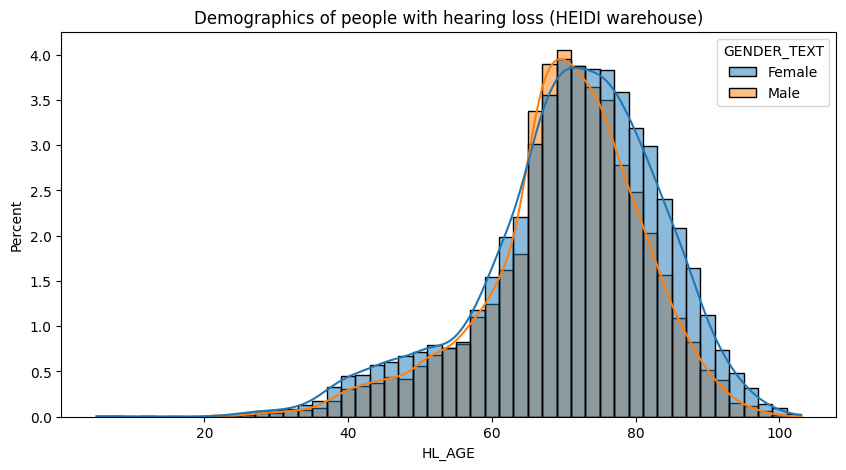

In [4]:
# 1. Demographics of people with hearing loss (HEIDI warehouse)

patron_hl_data = pd.read_csv(os.path.join(data_dir,'audiogram_HL_demographics.csv'))
filtered_df = patron_hl_data[patron_hl_data['GENDER_TEXT'] != 'Not Recorded']
plt.figure(figsize=(10, 5))
sn.histplot(data=filtered_df, x='HL_AGE', hue='GENDER_TEXT', kde=True, binwidth=2, stat='percent')
plt.title('Demographics of people with hearing loss (HEIDI warehouse)')
filtered_df['GENDER_TEXT'] = filtered_df['GENDER_TEXT'].astype('category')

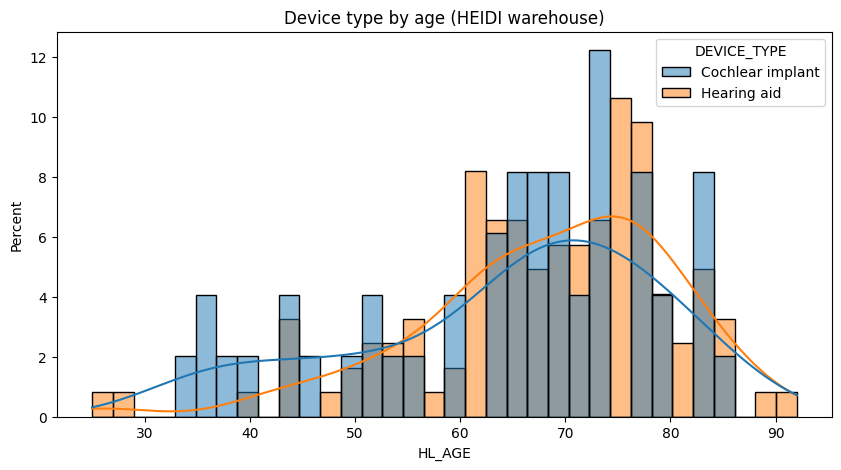

In [5]:
# 2. Device type by age (HEIDI warehouse)

patron_hl_data = pd.read_csv(os.path.join(data_dir,'audiogram_HL_demographics.csv'))

plt.figure(figsize=(10, 5))
sn.histplot(data=patron_hl_data, x='HL_AGE', hue='DEVICE_TYPE', kde=True, binwidth=2, stat='percent', common_norm=False)
plt.title('Device type by age (HEIDI warehouse)')
patron_hl_data['DEVICE_TYPE'] = patron_hl_data['DEVICE_TYPE'].astype('category')

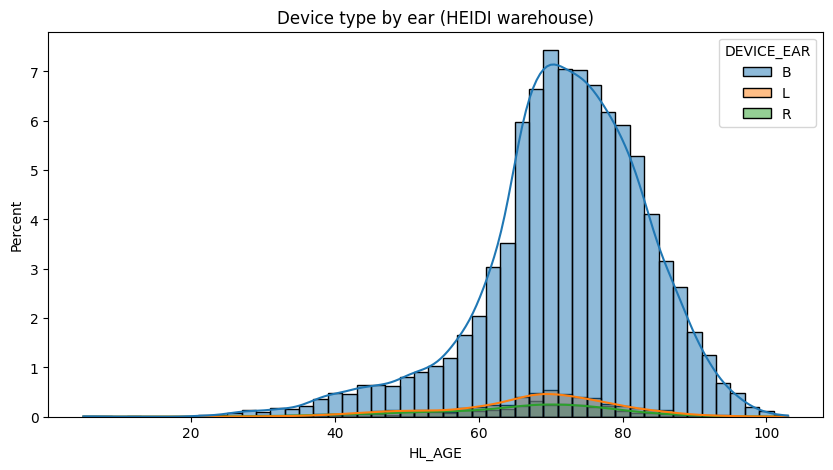

In [6]:
# 3. Device type by ear (HEIDI warehouse)
patron_hl_data = pd.read_csv(os.path.join(data_dir,'audiogram_HL_demographics.csv'))

plt.figure(figsize=(10, 5))
sn.histplot(data=patron_hl_data, x='HL_AGE', hue='DEVICE_EAR', kde=True, binwidth=2, stat='percent')
plt.title('Device type by ear (HEIDI warehouse)')
patron_hl_data['DEVICE_EAR'] = patron_hl_data['DEVICE_EAR'].astype('category')

Text(0.5, 1.0, 'Initial 3FAHL Right vs Age')

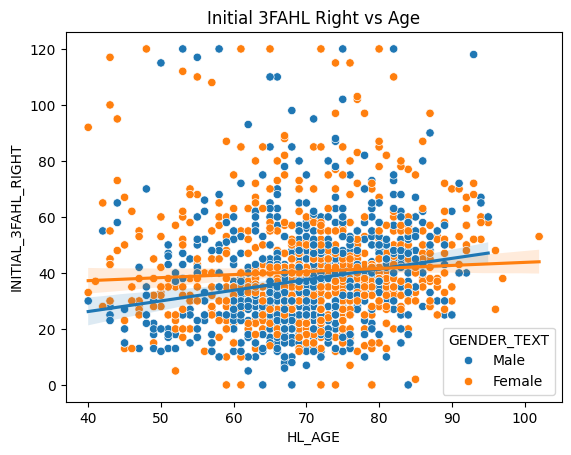

In [7]:
# 4. Inital 3FAHL Right vs Age
frank_patron_hl_data = pd.read_csv(os.path.join(data_dir,'frank_audiogram.csv'))
sampled_data = frank_patron_hl_data.sample(frac=0.1, random_state=1)

sn.scatterplot(data=sampled_data, x='HL_AGE', y='INITIAL_3FAHL_RIGHT', hue='GENDER_TEXT')

# Regression lines for each group
groups = sampled_data['GENDER_TEXT'].unique()
for group in groups:
    sn.regplot(y='INITIAL_3FAHL_RIGHT', x='HL_AGE', data=sampled_data[sampled_data['GENDER_TEXT'] == group], scatter=False, label=f'Group {group}')

plt.title('Initial 3FAHL Right vs Age')

Text(0.5, 1.0, 'Initial 3FAHL Left vs Age')

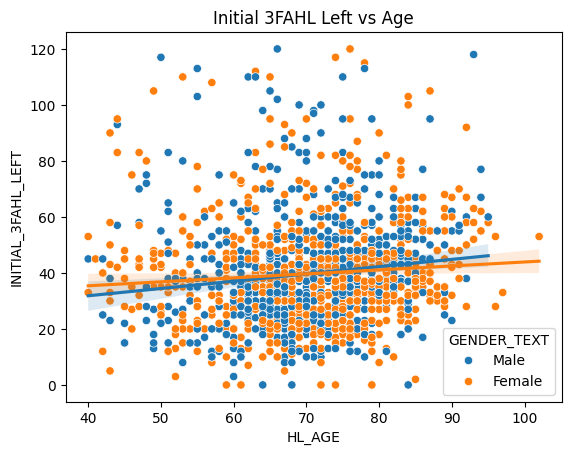

In [8]:
# 5. Inital 3FAHL Left vs Age
frank_patron_hl_data = pd.read_csv(os.path.join(data_dir,'frank_audiogram.csv'))
sampled_data = frank_patron_hl_data.sample(frac=0.1, random_state=1)

sn.scatterplot(data=sampled_data, y='INITIAL_3FAHL_LEFT', x='HL_AGE', hue='GENDER_TEXT')

# Regression lines for each group
groups = sampled_data['GENDER_TEXT'].unique()
for group in groups:
    sn.regplot(y='INITIAL_3FAHL_LEFT', x='HL_AGE', data=sampled_data[sampled_data['GENDER_TEXT'] == group], scatter=False, label=f'Group {group}')

plt.title('Initial 3FAHL Left vs Age')

<Axes: xlabel='FAHL3_LEFT', ylabel='HL_AGE'>

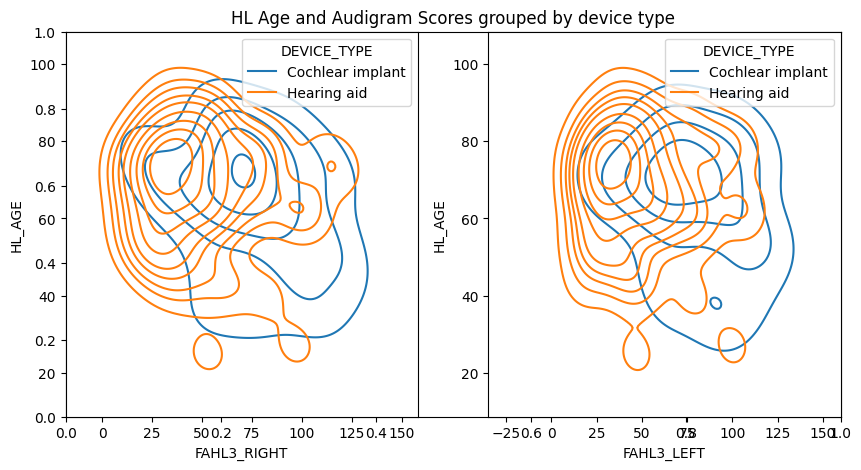

In [9]:
# 6 HL Age and Audigram Scores grouped by device type
patron_hl_data = pd.read_csv(os.path.join(data_dir,'audiogram_HL_demographics.csv'))
plt.figure(figsize=(10, 5))
plt.title('HL Age and Audigram Scores grouped by device type')
plt.subplot(1, 2, 1)
sn.kdeplot(data=patron_hl_data, x='FAHL3_RIGHT', y='HL_AGE', hue='DEVICE_TYPE')
plt.title('')
plt.subplot(1, 2, 2)
sn.kdeplot(data=patron_hl_data, x='FAHL3_LEFT', y='HL_AGE', hue='DEVICE_TYPE')

In [10]:
# 7 Descriptive Statistics Grouped By Gender
patron_hl_data = pd.read_csv(os.path.join(data_dir,'audiogram_HL_demographics.csv'))
warnings.simplefilter(action='ignore', category=FutureWarning)
patron_hl_data.set_index('PATIENT_ID').groupby('GENDER_TEXT').describe()

HL_AGE                                                       \
                count       mean        std   min   25%   50%   75%    max   
GENDER_TEXT                                                                  
Female        11846.0  70.804322  12.655771   5.0  64.0  72.0  79.0  103.0   
Male           9851.0  69.743173  11.231185   8.0  65.0  71.0  77.0  102.0   
Not Recorded      5.0  56.000000  14.560220  37.0  50.0  53.0  65.0   75.0   

             FAHL3_LEFT             ... L_4000          R_4000             \
                  count       mean  ...    75%    max    count       mean   
GENDER_TEXT                         ...                                     
Female          11846.0  39.239490  ...   65.0  120.0  11846.0  51.604339   
Male             9851.0  38.944574  ...   75.0  120.0   9851.0  62.231246   
Not Recorded        5.0  47.600000  ...   65.0   70.0      5.0  45.000000   

                                                        
                    std   min   25%   50%   75%    max  
GENDER_TEXT                                             
Female        21.805744  -5.0  35.0  50.0  65.0  120.0  
Male          20.602492   0.0  50.0  60.0  75.0  120.0  
Not Recorded  13.693064  30.0  35.0  45.0  50.0   65.0  

[3 rows x 104 columns]

In [11]:
# 8 Specsavers AU and NZ Age Range

au_data = pd.read_csv(os.path.join(data_dir,'AU_screeners_data.csv'))
nz_data = pd.read_csv(os.path.join(data_dir,'NZ_screeners_data.csv'))

au_ages = au_data.assign(
    age=pd.to_numeric(au_data['testDateTime'].str[-4:]) - pd.to_numeric(au_data['birthday']).to_numpy()
)
nz_ages = nz_data.assign(
    age=pd.to_numeric(nz_data['testDateTime'].str[-4:]) - pd.to_numeric(nz_data['birthday']).to_numpy()
)

min_au = np.min(au_ages['age'])
max_au = np.max(au_ages['age'])
min_nz = np.min(nz_ages['age'])
max_nz = np.max(nz_ages['age'])

print(f'AU participants: {len(au_ages)} [{min_au} - {max_au}]')
print(f'NZ participants {len(nz_ages)} [{min_nz} - {max_nz}]')

print(f'All participants {len(au_ages) + len(nz_ages)}')

AU participants: 2213560 [0 - 124]
NZ participants 382344 [0.0 - 124.0]
All participants 2595904


Text(0.5, 1.0, 'General demographics of SpecSavers participants (Australia)')

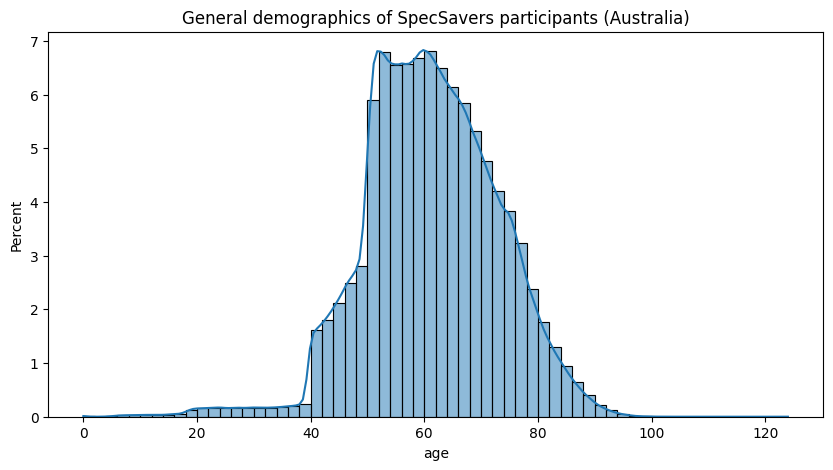

In [ ]:
# 9 General demographics of SpecSavers participants (Australia)
au_data = pd.read_csv(os.path.join(data_dir,'AU_screeners_data.csv'))
au_ages = au_data.assign(
    age=pd.to_numeric(au_data['testDateTime'].str[-4:]) - pd.to_numeric(au_data['birthday']).to_numpy()
)
plt.figure(figsize=(10, 5))
sn.histplot(data=au_ages, x='age', kde=True, stat='percent', binwidth=2)
plt.title('General demographics of SpecSavers participants (Australia)')

People with hearing loss 92.97% (SpecSavers Australia)


Text(0.5, 1.0, 'General demographics of SpecSavers participants (Australia) with 3FAHL > 20dB')

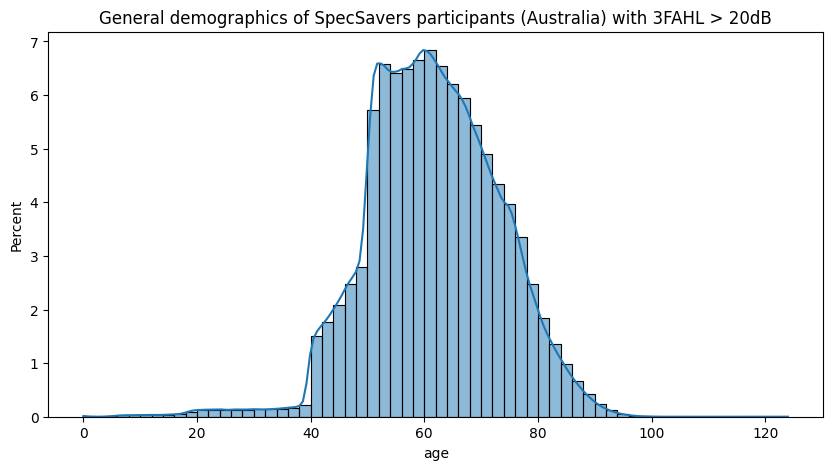

In [9]:
# 10 General demographics of SpecSavers participants (Australia) with 3FAHL > 20dB
au_data = pd.read_csv(os.path.join(data_dir,'AU_screeners_data.csv'))
au_ages = au_data.assign(
    age=pd.to_numeric(au_data['testDateTime'].str[-4:]) - pd.to_numeric(au_data['birthday']).to_numpy()
)
au_fahl = au_ages.assign(
    fahl3Left=(
        (
            pd.to_numeric(au_ages['hlLeft.freq500']) +
            pd.to_numeric(au_ages['hlLeft.freq1000']) +
            pd.to_numeric(au_ages['hlLeft.freq2000'])
        ) / 3
    ).to_numpy()
)
au_fahl = au_fahl.assign(
    fahl3Right=(
        (
            pd.to_numeric(au_ages['hlRight.freq500']) +
            pd.to_numeric(au_ages['hlRight.freq1000']) +
            pd.to_numeric(au_ages['hlRight.freq2000'])
        ) / 3
    ).to_numpy()
)

spec_au_hl = au_fahl[(au_fahl['fahl3Right'] > 20) | (au_fahl['fahl3Left'] > 20)]

print('People with hearing loss {:5.2f}% (SpecSavers Australia)'.format(100 * len(spec_au_hl) / len(au_fahl)))

plt.figure(figsize=(10, 5))
sn.histplot(data=spec_au_hl, x='age', kde=True, stat='percent', binwidth=2)
plt.title('General demographics of SpecSavers participants (Australia) with 3FAHL > 20dB')

In [ ]:
# 11 Demographics of Specsaver entries with hearing loss
au_fahl = au_ages.assign(
    fahl3Left=(
        (
            pd.to_numeric(au_ages['hlLeft.freq500']) +
            pd.to_numeric(au_ages['hlLeft.freq1000']) +
            pd.to_numeric(au_ages['hlLeft.freq2000'])
        ) / 3
    ).to_numpy()
)
au_fahl = au_fahl.assign(
    fahl3Right=(
        (
            pd.to_numeric(au_ages['hlRight.freq500']) +
            pd.to_numeric(au_ages['hlRight.freq1000']) +
            pd.to_numeric(au_ages['hlRight.freq2000'])
        ) / 3
    ).to_numpy()
)

spec_au_hl = au_fahl[(au_fahl['fahl3Right'] > 20) | (au_fahl['fahl3Left'] > 20)]

spec_demo = spec_au_hl.loc[:, 
    ~spec_au_hl.columns.str.contains('freq') &
    ~spec_au_hl.columns.str.contains('birthday') &
    ~spec_au_hl.columns.str.contains('Date')
]
filt_spec_demo = spec_demo[spec_demo['age'] > 45]

filt_spec_demo.describe()


,age,fahl3Left,fahl3Right
count,1.910926e+06,1.910926e+06,1.910926e+06
mean,6.318920e+01,3.187189e+01,3.364047e+01
std,9.842331e+00,9.623001e+00,1.024150e+01
min,4.600000e+01,1.000000e+01,1.000000e+01
25%,5.500000e+01,2.666667e+01,2.666667e+01
50%,6.200000e+01,3.000000e+01,3.000000e+01
75%,7.000000e+01,3.333333e+01,3.666667e+01
max,1.240000e+02,8.000000e+01,8.000000e+01


In [15]:
# 12 Age range of Specsaver entries with hearing loss
range_spec_demo = filt_spec_demo.assign(
    age=filt_spec_demo['age'] // 10 * 10
)
range_spec_demo.groupby('age').describe()

fahl3Left                                                               \
        count       mean        std   min        25%        50%        75%   
age                                                                          
40   108123.0  29.565680   7.092583  10.0  26.666667  30.000000  33.333333   
50   656115.0  29.728396   7.762970  10.0  26.666667  30.000000  33.333333   
60   637314.0  31.236952   8.759917  10.0  26.666667  30.000000  33.333333   
70   391545.0  34.336615  10.657987  10.0  26.666667  33.333333  36.666667   
80   108594.0  40.526057  13.405378  10.0  30.000000  36.666667  46.666667   
90     9144.0  48.738699  15.013808  10.0  36.666667  46.666667  56.666667   
100      54.0  54.012346  20.077206  10.0  38.333333  53.333333  73.333333   
110       4.0  31.666667   3.333333  30.0  30.000000  30.000000  31.666667   
120      33.0  35.757576  19.225864  10.0  26.666667  30.000000  40.000000   

               fahl3Right                                              \
           max      count       mean        std        min        25%   
age                                                                     
40   80.000000   108123.0  30.856648   7.539510  10.000000  26.666667   
50   80.000000   656115.0  31.211861   8.239533  10.000000  26.666667   
60   80.000000   637314.0  32.979865   9.350039  10.000000  26.666667   
70   80.000000   391545.0  36.455554  11.268523  10.000000  30.000000   
80   80.000000   108594.0  43.264484  13.919897  10.000000  33.333333   
90   80.000000     9144.0  51.868256  14.901924  10.000000  40.000000   
100  80.000000       54.0  56.543210  16.772781  23.333333  43.333333   
110  36.666667        4.0  39.166667  11.979921  30.000000  32.500000   
120  80.000000       33.0  38.787879  16.474268  16.666667  26.666667   

                                      
           50%        75%        max  
age                                   
40   30.000000  33.333333  80.000000  
50   30.000000  33.333333  80.000000  
60   30.000000  36.666667  80.000000  
70   33.333333  40.000000  80.000000  
80   40.000000  50.000000  80.000000  
90   50.000000  60.000000  80.000000  
100  56.666667  72.500000  80.000000  
110  35.000000  41.666667  56.666667  
120  30.000000  53.333333  80.000000

Text(0.5, 1.0, '3FAHL right by age')

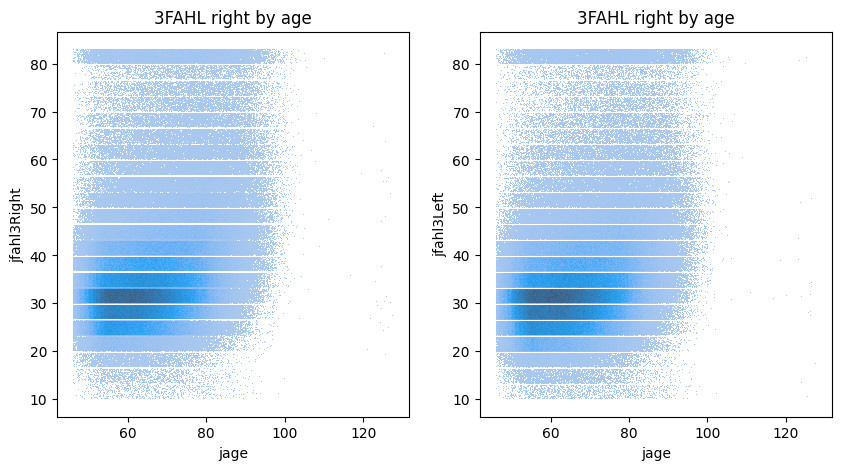

In [ ]:
# 13 Specsavers Jitter 3FAHL Right by Age
jitter_right = filt_spec_demo.assign(
    jfahl3Right=filt_spec_demo['fahl3Right'] + np.random.rand(len(filt_spec_demo)) * 3
)
jitter_right = jitter_right.assign(
    jage=filt_spec_demo['age'] + np.random.rand(len(filt_spec_demo)) * 5
)
jitter_left = filt_spec_demo.assign(
    jfahl3Left=filt_spec_demo['fahl3Left'] + np.random.rand(len(filt_spec_demo)) * 3
)
jitter_left = jitter_left.assign(
    jage=filt_spec_demo['age'] + np.random.rand(len(filt_spec_demo)) * 5
)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sn.histplot(data=jitter_right, x='jage', y='jfahl3Right')
plt.title('3FAHL right by age')
plt.subplot(1, 2, 2)
sn.histplot(data=jitter_left, x='jage', y='jfahl3Left')
plt.title('3FAHL right by age')

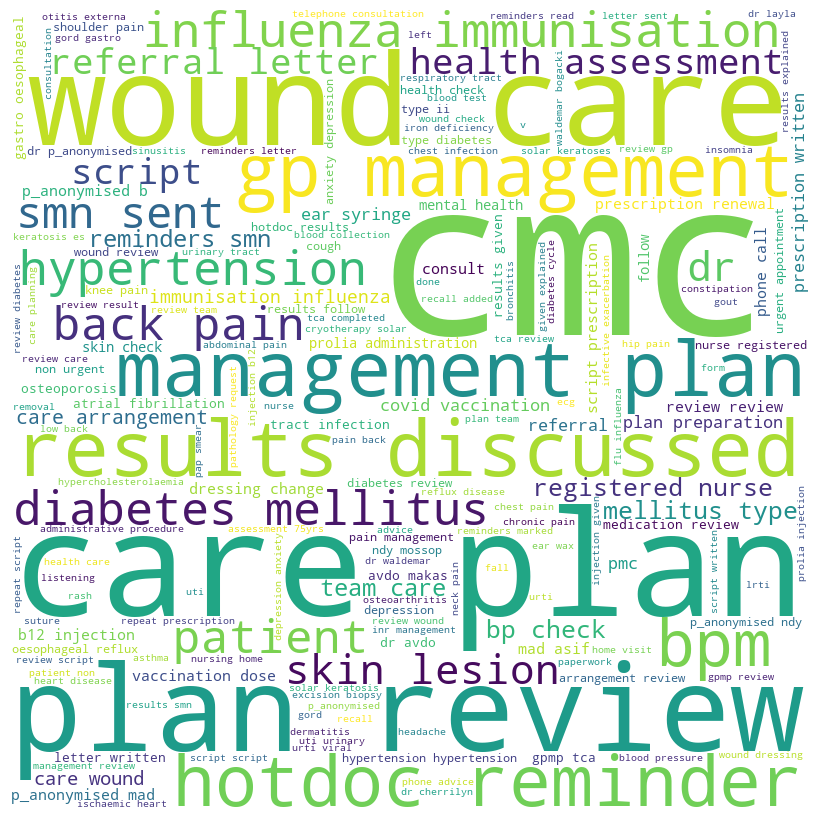

In [ ]:
# 14 VisitReasons WordCloud v1

df = pd.read_csv(os.path.join(data_dir, "visit_reasons_before_hl.csv"), encoding ="latin-1", header=None, names=['reasons'])

comment_words = ''
stopwords = set(STOPWORDS)

# iterate through the csv file
for val in df['reasons']:

    # typecaste each val to string
    val = str(val)

    # split the value
    tokens = val.split()

    # Converts each token into lowercase
    for i in range(len(tokens)):
        tokens[i] = tokens[i].lower()

    comment_words += " ".join(tokens)+" "

wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                stopwords = stopwords,
                min_font_size = 10).generate(comment_words)

# plot the WordCloud image
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()


4300951 713395


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

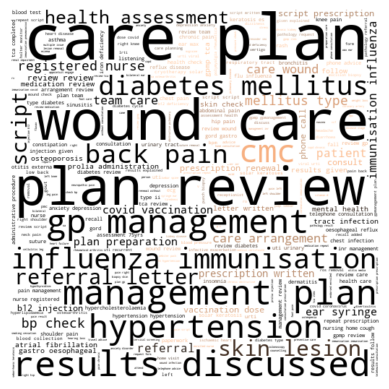

In [ ]:
# 15 VisitReasons WordCloud v2

df = pd.read_csv(os.path.join(data_dir, "visit_reasons_before_hl.csv"), encoding ="latin-1", header=None, names=['reasons'])
heidi_coloring = np.array(Image.open(os.path.join(data_dir,"ear.png")))
comment_words = ''
stopwords = set(STOPWORDS)
 
# iterate through the csv file
for row in df['reasons']:
 
    # print(row)
    # split the value
    tokens = str(row).split(' ')
    # Converts each token into lowercase
    for i in range(len(tokens)):
        tokens[i] = tokens[i].lower()
 
    if 'p_anonym' in " ".join(tokens)+" " or 'hotdoc' in " ".join(tokens)+" " or 'dr' in " ".join(tokens)+" ":
        continue
    comment_words += " ".join(tokens)+" "
 
print(len(comment_words), len(comment_words.split(' ')))
wc = WordCloud(
    background_color ='white',
    max_words=2000,
    mask = heidi_coloring,
    stopwords = stopwords,
    contour_width=3,
    # min_font_size = 5
)
 
# generate word cloud
wc.generate(comment_words)
 
# create coloring from image
image_colors = ImageColorGenerator(heidi_coloring)
 
# show
plt.figure()
plt.imshow(wc.recolor(color_func=image_colors), interpolation="bilinear")
plt.axis('off')
 

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

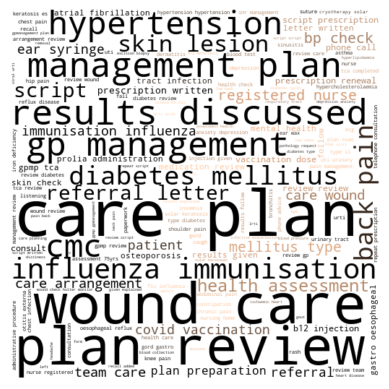

In [24]:
# 16 VisitReasons WordCloud v3
wc = WordCloud(
    width = 800, height = 800,
    background_color ='white',
    stopwords = stopwords,
    mask = heidi_coloring,
    contour_width=10,
    min_font_size = 5
)
 
# generate word cloud
wc.generate(comment_words)
 
# create coloring from image
image_colors = ImageColorGenerator(heidi_coloring)
 
# show
plt.figure()
plt.imshow(wc.recolor(color_func=image_colors), interpolation="bilinear")
plt.axis('off')